# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


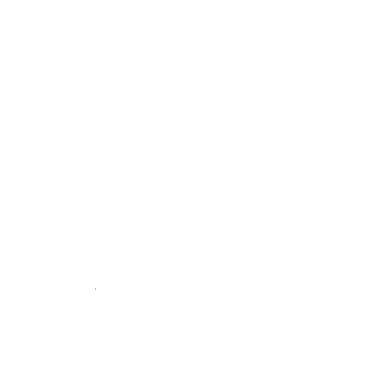

Threshold value: 50


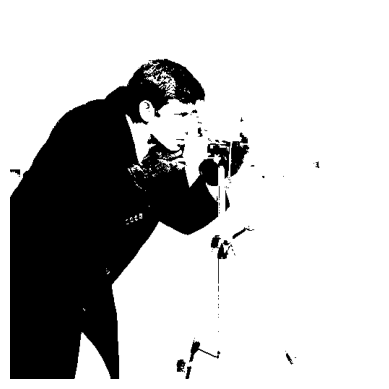

Threshold value: 100


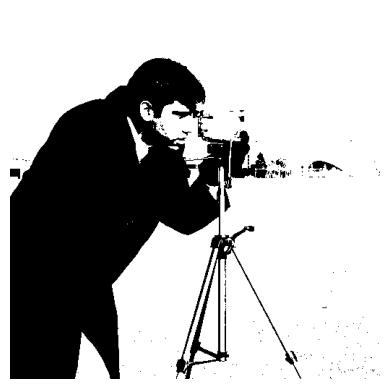

Threshold value: 150


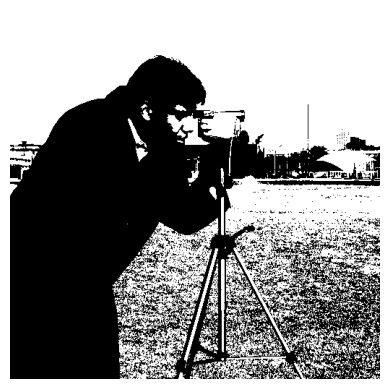

Threshold value: 200


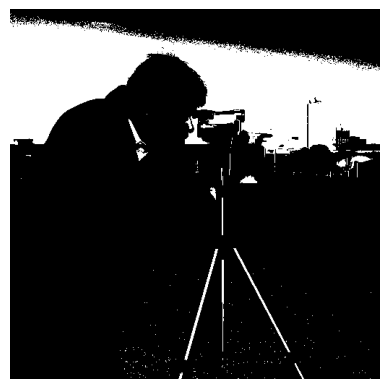

In [3]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    _, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print("Threshold value:", threshold_value)

    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image:


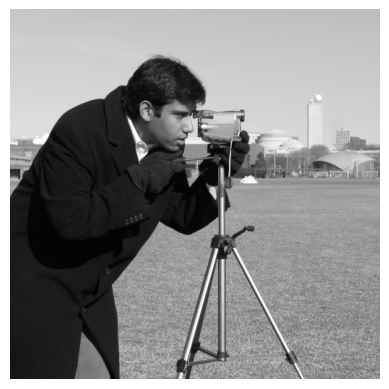

In [4]:
print("Original Image:")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

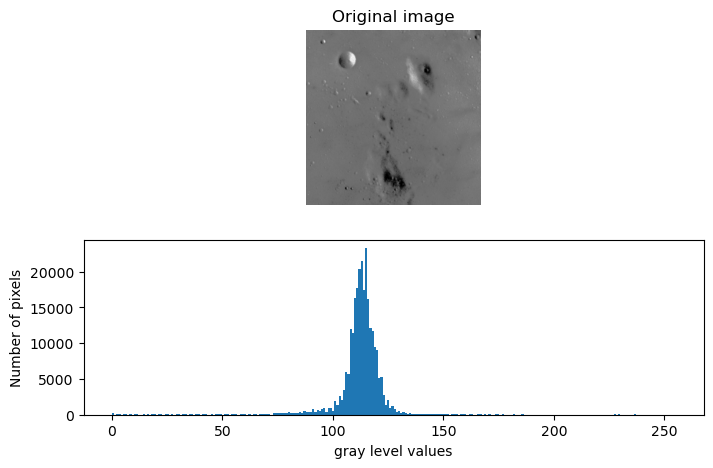

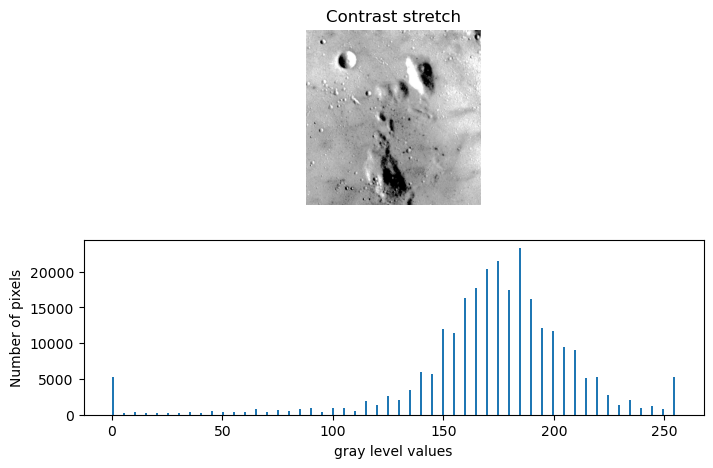

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


3rd percentile: 87.0
80th percentile: 118.0


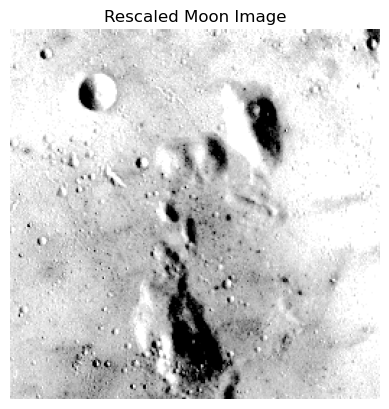

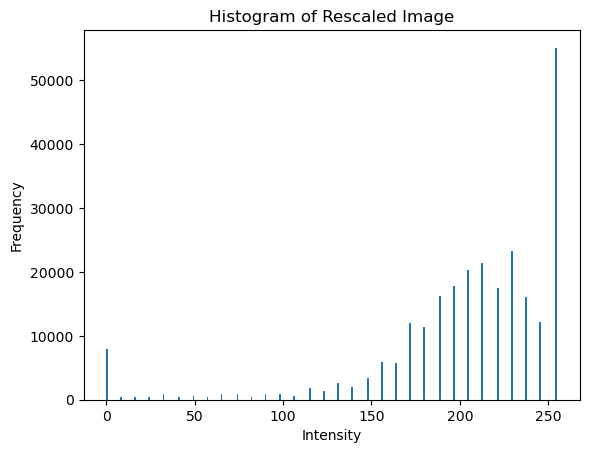

In [6]:
import cv2
import matplotlib.pyplot as plt
from skimage import data
import numpy as np

# Load moon image
img = data.moon()

# Find the 3rd and 80th percentiles
p3 = np.percentile(img, 3)
p80 = np.percentile(img, 80)

print("3rd percentile:", p3)
print("80th percentile:", p80)

# Rescale intensities between the 3rd and 80th percentiles to 0-255
rescaled_img = np.clip((img - p3) * 255 / (p80 - p3), 0, 255).astype(np.uint8)

# Display rescaled image
plt.imshow(rescaled_img, cmap='gray')
plt.title("Rescaled Moon Image")
plt.axis('off')
plt.show()

# Plot histogram
plt.hist(rescaled_img.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of Rescaled Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

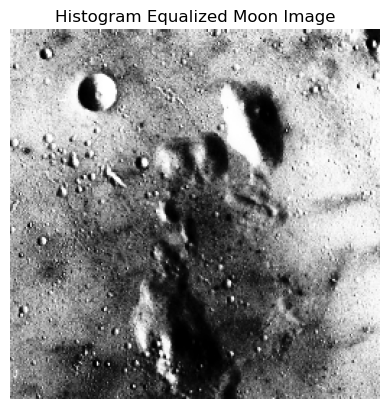

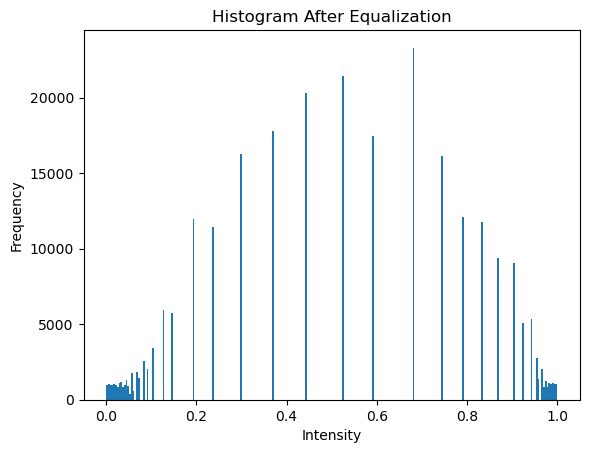

In [7]:
import matplotlib.pyplot as plt
from skimage import data, exposure

# Load moon image
img = data.moon()

# Apply histogram equalization
equalized_img = exposure.equalize_hist(img)

# Display the equalized image
plt.imshow(equalized_img, cmap='gray')
plt.title("Histogram Equalized Moon Image")
plt.axis('off')
plt.show()

# Display the histogram
plt.hist(equalized_img.ravel(), bins=256, range=(0, 1))
plt.title("Histogram After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

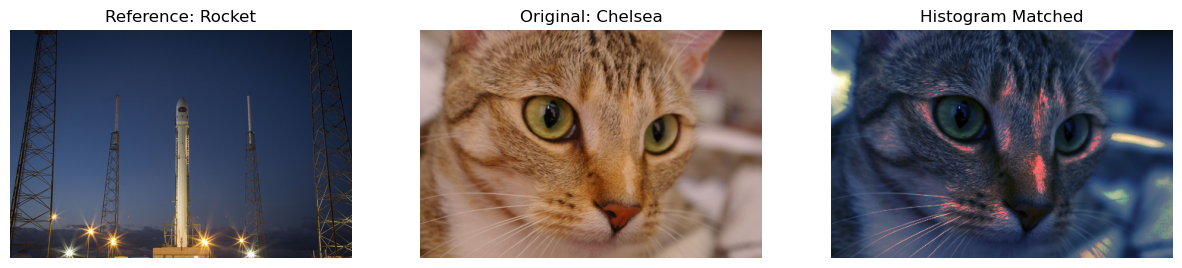

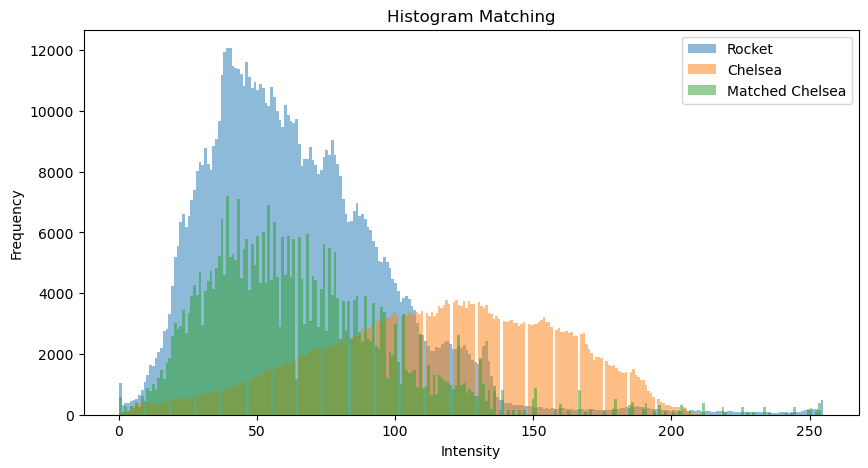

In [8]:
import matplotlib.pyplot as plt
from skimage import data, exposure

# images
rocket = data.rocket()
chelsea = data.chelsea()
# match
matched = exposure.match_histograms(chelsea, rocket, channel_axis=-1)

# plot images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rocket)
axes[0].set_title("Reference: Rocket")
axes[0].axis('off')

axes[1].imshow(chelsea)
axes[1].set_title("Original: Chelsea")
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title("Histogram Matched")
axes[2].axis('off')

plt.show()

# histograms
plt.figure(figsize=(10, 5))

plt.hist(rocket.ravel(), bins=256, alpha=0.5, label='Rocket')
plt.hist(chelsea.ravel(), bins=256, alpha=0.5, label='Chelsea')
plt.hist(matched.ravel(), bins=256, alpha=0.5, label='Matched Chelsea')

plt.title("Histogram Matching")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()